# AI/R&D Assignment

## Problem Statement
We are given the parametric equations of a curve:
$$ x = t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta) + X $$
$$ y = 42 + t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta) $$

And a set of points $(x, y)$ that lie on this curve for some parameter $t \in (6, 60)$. We need to find the values of the unknown variables $\theta, M, X$.



## 1. Exploratory Data Analysis
Before jumping into solving for the parametric equation, let's first explore the provided dataset `xy_data.csv`. This will help us understand the distribution, bounds, and general shape of the points we need to fit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

# Load the dataset
df = pd.read_csv(r"D:\Downloads\flam\FlamApp-RnD-Assignment\data\xy_data.csv")
x_data = df['x'].values
y_data = df['y'].values


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1500 non-null   float64
 1   y       1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


In [3]:
df.describe()

,x,y
count,1500.000000,1500.000000
mean,83.713931,58.263519
std,13.697157,7.696524
min,59.657204,46.032295
25%,72.282910,51.124211
50%,84.710995,57.681288
75%,93.368257,66.138374
max,109.231520,69.685510


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 2)


From the summary statistics, we observe the ranges of our $x$ and $y$ variables. Let's visualize the raw data to see the curve's structure. Since it is a parametric curve, the points should follow a specific trajectory.

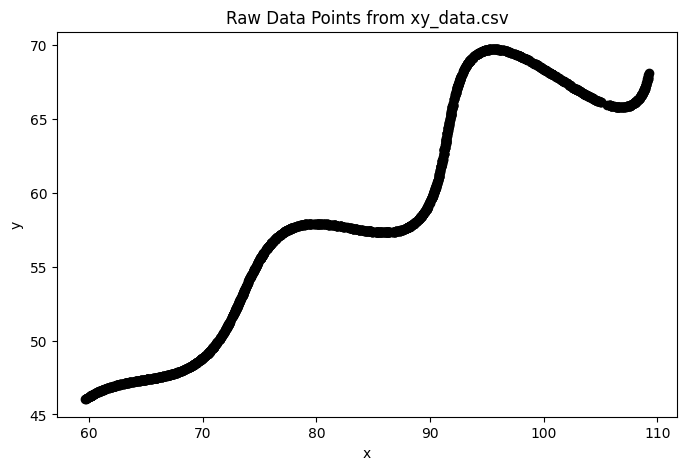

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, color='black')
plt.title('Raw Data Points from xy_data.csv')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


# 2. Initial Attempt: 

After understanding the problem, the first idea was to directly compare the generated curve with the given dataset.

The assumption was that the points in the dataset were arranged in the same order as the parameter \(t\). Based on this assumption, the generated curve was sampled using uniformly spaced values of \(t\), and the corresponding points were compared using an L1 distance.

This seemed like a straightforward way to estimate the unknown parameters before trying more advanced approaches.

In [6]:
def naive_loss(params):

    theta, M, X = params

    # Convert degrees to radians for trigonometric functions
    theta = np.deg2rad(theta)

    # Initial assumption:
    # Dataset rows correspond to uniformly increasing values of t.
    t = np.linspace(6, 60, len(x_data))

    x_pred = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
        + X
    )

    y_pred = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    # L1 Loss (matches assignment evaluation)
    error = (
        np.mean(np.abs(x_data - x_pred))
        + np.mean(np.abs(y_data - y_pred))
    )

    return error

### 2. Nelder-Mead on Naive Loss


In [20]:
import time

np.random.seed(42)

best_loss = float("inf")
best_params = None

start = time.time()

# Randomly sample 10000 parameter combinations
for _ in range(10000):

    theta_guess = np.random.uniform(0, 50)
    M_guess = np.random.uniform(-0.05, 0.05)
    X_guess = np.random.uniform(0, 100)

    loss = naive_loss([theta_guess, M_guess, X_guess])

    if loss < best_loss:
        best_loss = loss
        best_params = [theta_guess, M_guess, X_guess]

end = time.time()

print("Random Search Results")
print("-" * 40)
print(f"Theta : {best_params[0]:.2f}°")
print(f"M     : {best_params[1]:.6f}")
print(f"X     : {best_params[2]:.4f}")
print(f"\nBest L1 Loss : {best_loss:.6f}")
print(f"Execution Time : {end-start:.2f} seconds")

Random Search Results
----------------------------------------
Theta : 28.31°
M     : 0.011215
X     : 54.9251

Best L1 Loss : 25.265734
Execution Time : 1.53 seconds


### 2. Nelder-Mead on Naive Loss

In [21]:
from scipy.optimize import minimize
import time

# Initial guess (degrees, M, X)
x0 = [25, 0, 50]

start = time.time()

res_nm = minimize(
    naive_loss,
    x0,
    method="Nelder-Mead"
)

end = time.time()

print("Nelder-Mead Results")
print("-" * 40)
print(f"Theta : {res_nm.x[0]:.2f}°")
print(f"M     : {res_nm.x[1]:.6f}")
print(f"X     : {res_nm.x[2]:.4f}")
print(f"\nBest L1 Loss : {res_nm.fun:.6f}")
print(f"Iterations : {res_nm.nit}")
print(f"Execution Time : {end-start:.2f} seconds")

Nelder-Mead Results
----------------------------------------
Theta : 28.12°
M     : 0.021389
X     : 54.8992

Best L1 Loss : 25.243396
Iterations : 122
Execution Time : 0.05 seconds
